# Suggestion Impact Analysis

This analysis loads all suggestion impact CSV files from the `test-results/suggestion-impacts/` directory, aggregates the data by model, and computes summary statistics:

1. Total number of suggestions for each model
2. Percentage of suggestions accepted (A_and_B)
3. Percentage of suggestions rejected (not_A_and_B)
4. Percentage of suggestions not applicable (A_and_not_B and not_A_and_not_B)
5. A summary table with these metrics for each model

In [5]:
import os
import glob
import pandas as pd

In [ ]:
# Define the root directory containing model subdirectories
root_dir = '../test-results/suggestion-impacts/'

# Find all CSV files in all subdirectories
csv_files = glob.glob(os.path.join(root_dir, '*', '*.csv'))

# Load all CSVs into a single DataFrame
all_dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    # Optionally add modelname from directory if not present
    if 'modelname' not in df.columns:
        model = os.path.basename(os.path.dirname(file))
        df['modelname'] = model
    all_dfs.append(df)

# Concatenate all dataframes
all_data = pd.concat(all_dfs, ignore_index=True)

# Display the first few rows
all_data.head()

ValueError: No objects to concatenate

Bad pipe message: %s [b">\x19\x07\x1aOq\xfa\xa6\x82\x1d\xa3t'\x16\x88\x84\xda`\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6"]
Bad pipe message: %s [b'\x99\x9d\xa0Fr\x8b\xc6\x96\xe1\x95\xb2$\x16ko\xdd@\x83\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00', b'\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00']
Bad pipe message: %s [b'\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001']
Bad pipe mes

In [ ]:
# Group by modelname and sum relevant columns
summary = all_data.groupby('modelname')[['A_and_B', 'A_and_not_B', 'not_A_and_B', 'not_A_and_not_B']].sum()

# Calculate total suggestions per model
summary['total'] = summary.sum(axis=1)

# Calculate percentages
summary['A_and_B%'] = 100 * summary['A_and_B'] / summary['total']
summary['not_A_and_B%'] = 100 * summary['not_A_and_B'] / summary['total']
summary['A_and_not_B%'] = 100 * summary['A_and_not_B'] / summary['total']
summary['not_A_and_not_B%'] = 100 * summary['not_A_and_not_B'] / summary['total']

# Display the summary table
summary = summary[['total', 'A_and_B%', 'not_A_and_B%', 'A_and_not_B%', 'not_A_and_not_B%']]
summary.round(2)

,total,A_and_B%,not_A_and_B%,A_and_not_B%,not_A_and_not_B%
modelname,,,,,
array,9,44.444444,0.0,44.444444,11.111111
bempl,92,56.521739,0.0,43.478261,0.0
binary-tree,692,49.855491,0.0,48.843931,1.300578
c-tree,947,55.649419,0.0,44.350581,0.0
class-diagram,171,51.461988,0.0,48.538012,0.0
classroom-fol,3633,52.436003,0.0,47.013487,0.550509
classroom-rl,2269,53.063023,0.0,46.936977,0.0
courses-v1,1394,50.286944,0.0,44.906743,4.806313
courses-v2,2354,49.702634,0.0,46.091759,4.205607


## Summary Table

The table below shows, for each model:
- The total number of suggestions
- The percentage of suggestions accepted
- The percentage of suggestions rejected
- The percentage of suggestions not applicable

/var/folders/bg/ffcr6gyx1jl8m4wzqvpsfmxh0000gn/T/ipykernel_84361/622681616.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['total'], palette="Blues_d")


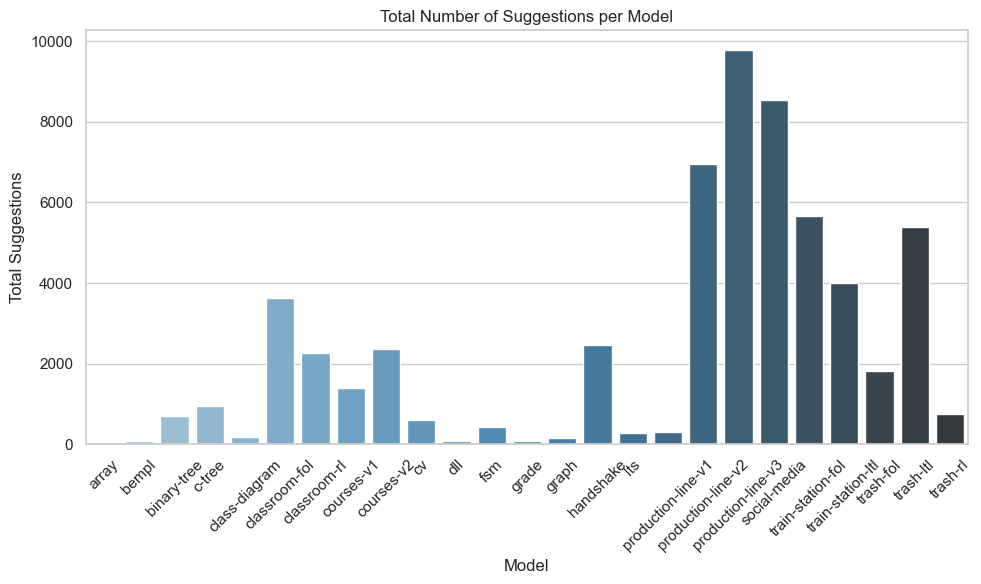

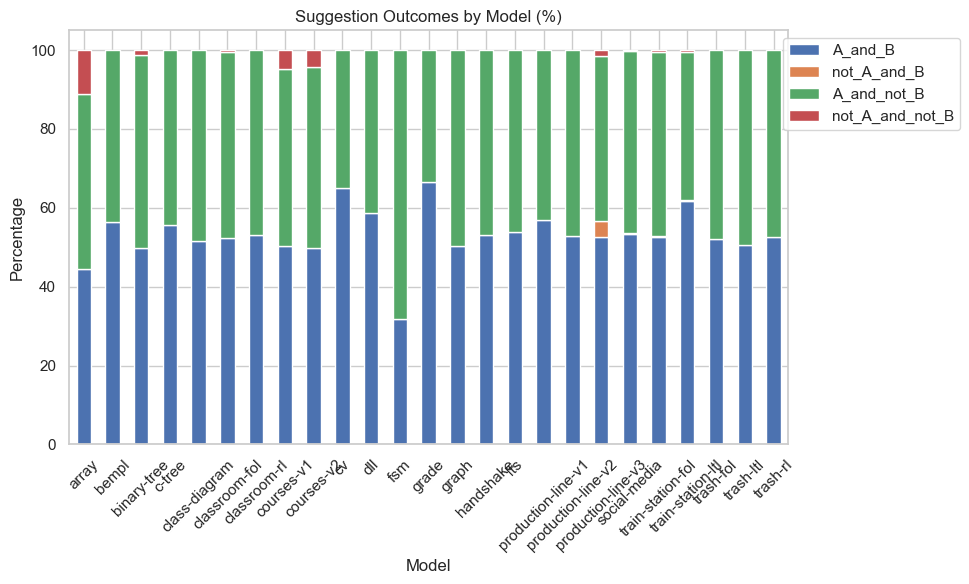

In [ ]:
# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Bar chart: total number of suggestions per model
plt.figure(figsize=(10, 6))
sns.barplot(x=summary.index, y=summary['total'], palette="Blues_d")
plt.title('Total Number of Suggestions per Model')
plt.xlabel('Model')
plt.ylabel('Total Suggestions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar chart: percentage breakdown per model
percentages = summary[['A_and_B%', 'not_A_and_B%', 'A_and_not_B%', 'not_A_and_not_B%']]
percentages.columns = ['A_and_B', 'not_A_and_B', 'A_and_not_B', 'not_A_and_not_B']

percentages.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Suggestion Outcomes by Model (%)')
plt.xlabel('Model')
plt.ylabel('Percentage')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()